In [4]:
# !pip install netCDF4
!pip install matplotlib

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 8.7 MB/s eta 0:00:0000:01m0:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 25.0 MB/s eta 0:00:00


In [6]:
!pip install cartopy

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 16.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 17.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 15.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 17.1 MB/s eta 0:00:0000:0100:01


In [7]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [12]:
# 读取NetCDF文件
# file_path = 'CLDMSK_L2_VIIRS_SNPP.A2022001.0000.001.2022001134237.nc'
file_path = "/root/autodl-fs/2022/20220101/20220101_lat-16.79_lon83.69_l3s.nc"
# file_path = "D:\\PYPro\\modis\\eval\\l3s\\download\\L3S_LEO_PM-STAR-v2.81_2.81-20260214_093110\\20220101120000-STAR-L3S_GHRSST-SSTsubskin-LEO_PM_N-ACSPO_V2.81-v02.0-fv01.0.nc"
dataset = nc.Dataset(file_path, 'r')

In [13]:
print("=" * 60)
print("数据集基本信息")
print("=" * 60)

# 1. 查看数据集的全局属性
print("\n全局属性:")
for attr in dataset.ncattrs():
    print(f"  {attr}: {dataset.getncattr(attr)}")

数据集基本信息

全局属性:
  source: GHRSST L3S LEO_PM
  center_lat: -16.790000915527344
  center_lon: 83.69000244140625
  lat_idx_start: 3712
  lon_idx_start: 13056
  ocean_ratio: 1.0
  missing_rate: 0.096954345703125
  creation_date: 2026-02-19 18:52:10


In [14]:
# 2. 查看所有变量
print("\n" + "=" * 60)
print("数据变量列表")
print("=" * 60)
for var_name in dataset.variables.keys():
    var = dataset.variables[var_name]
    print(f"\n变量名: {var_name}")
    print(f"  维度: {var.dimensions}")
    print(f"  形状: {var.shape}")
    print(f"  数据类型: {var.dtype}")
    # if hasattr(var, 'long_name'):
    #     print(f"  长名称: {var.long_name}")
    # if hasattr(var, 'units'):
    #     print(f"  单位: {var.units}")
    if hasattr(var, 'valid_range'):
        print(f"  有效范围: {var.valid_range}")

    # 变量属性
    if var.ncattrs():
        print("  属性:")
        for attr in var.ncattrs():
            print(f"    {attr}: {var.getncattr(attr)}")

# 3. 读取坐标变量
print("\n" + "=" * 60)
print("坐标信息")
print("=" * 60)

longitude = 'lon'
latitude = 'lat'

if longitude in dataset.variables:
    lon = dataset.variables[longitude][:]
    # print(lon)
    print(f"经度范围: {lon.min():.2f}° 到 {lon.max():.2f}°")
    print(f"经度网格点数: {len(lon)}")

if latitude in dataset.variables:
    lat = dataset.variables[latitude][:]
    # print(lat)
    print(f"纬度范围: {lat.min():.2f}° 到 {lat.max():.2f}°")
    print(f"纬度网格点数: {len(lat)}")

if 'time' in dataset.variables:
    time = dataset.variables['time'][:]
    print(f"时间步数: {len(time)}")
    if hasattr(dataset.variables['time'], 'units'):
        print(f"时间单位: {dataset.variables['time'].units}")

if 'depth' in dataset.variables or 'lev' in dataset.variables:
    depth_var = 'depth' if 'depth' in dataset.variables else 'lev'
    depth = dataset.variables[depth_var][:]
    print(f"深度层数: {len(depth)}")
    print(f"深度范围: {depth.min():.2f} 到 {depth.max():.2f} m")


数据变量列表

变量名: lat
  维度: ('lat',)
  形状: (256,)
  数据类型: float32
  属性:
    long_name: latitude
    units: degrees_north

变量名: lon
  维度: ('lon',)
  形状: (256,)
  数据类型: float32
  属性:
    long_name: longitude
    units: degrees_east

变量名: time
  维度: ('time',)
  形状: (1,)
  数据类型: int32
  属性:
    long_name: reference time of sst file
    units: seconds since 1981-01-01 00:00:00
    comment: seconds since 1981-01-01 00:00:00
    standard_name: time
    calendar: Gregorian
    axis: T
    coverage_content_type: coordinate

变量名: sea_surface_temperature
  维度: ('time', 'lat', 'lon')
  形状: (1, 256, 256)
  数据类型: int16
  属性:
    _FillValue: -32768
    add_offset: 273.1499938964844
    comment: SST obtained by regression with buoy measurements, sensitive to skin SST. Further information at (Petrenko et al., JGR, 2014; doi:10.1002/2013JD020637)
    coordinates: lon lat
    coverage_content_type: physicalMeasurement
    long_name: sea surface sub-skin temperature
    scale_factor: 0.009999999776482582
    


生成可视化


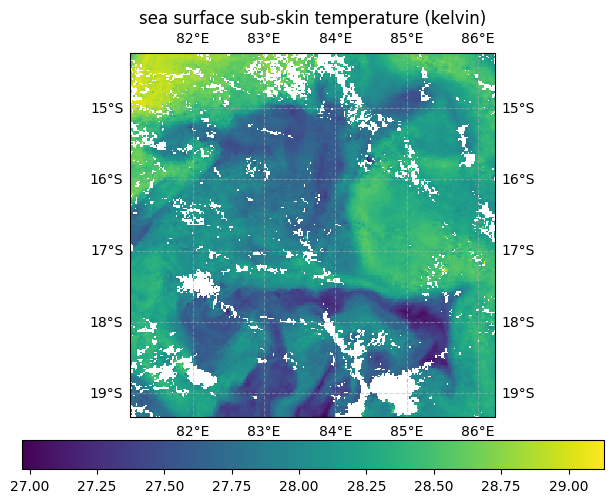

In [17]:
# 4. 可视化示例（如果存在常见的海洋变量）
print("\n" + "=" * 60)
print("生成可视化")
print("=" * 60)

# 尝试绘制海表温度(SST)或其他表层变量
plot_vars = []
for var_name in ['sea_surface_temperature']:
    if var_name in dataset.variables:
        plot_vars.append(var_name)

if plot_vars and 'lon' in dataset.variables and 'lat' in dataset.variables:
    lon = dataset.variables['lon'][:]
    lat = dataset.variables['lat'][:]

    # 创建2D网格
    if lon.ndim == 1 and lat.ndim == 1:
        lon_2d, lat_2d = np.meshgrid(lon, lat)
    else:
        lon_2d, lat_2d = lon, lat

    fig = plt.figure(figsize=(15, 10))

    for idx, var_name in enumerate(plot_vars[:4], 1):  # 最多绘制4个变量
        var = dataset.variables[var_name] 

        # 获取第一个时间步的数据
        if var.ndim == 4:  # (time, depth, lat, lon)
            data = var[0, 0, :, :]
        elif var.ndim == 3:  # (time, lat, lon)
            data = var[0, :, :] - 273.15
        elif var.ndim == 2:  # (lat, lon)
            data = var[:, :]
        else:
            continue

        # 处理masked数据
        if isinstance(data, np.ma.MaskedArray):
            data = np.ma.filled(data, np.nan)

        ax = fig.add_subplot(2, 2, idx, projection=ccrs.PlateCarree())

        # 绘制数据
        im = ax.pcolormesh(lon_2d, lat_2d, data,
                           transform=ccrs.PlateCarree(),
                           cmap='viridis', shading='auto')

        # 添加地理特征
        ax.coastlines(resolution='10m')
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

        # 标题和颜色条
        title = var.long_name if hasattr(var, 'long_name') else var_name
        units = f" ({var.units})" if hasattr(var, 'units') else ""
        ax.set_title(f"{title}{units}")
        plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)

    plt.tight_layout()
    # plt.savefig('hycom_data_visualization.png', dpi=300, bbox_inches='tight')
    # print("已保存可视化图像: hycom_data_visualization.png")
    plt.show()
else:
    print("未找到可绘制的变量或坐标信息")

In [18]:
# 关闭数据集
dataset.close()
print("\n" + "=" * 60)
print("数据探索完成！")
print("=" * 60)


数据探索完成！


In [1]:
# debug_dataset.py
import json
import torch
from torch.utils.data import DataLoader
from sst_dataset import SSTDataset, load_norm_stats

norm_params = load_norm_stats("norm_stats.json")
dataset = SSTDataset(
    data_root="/root/autodl-tmp",
    years=[2020],
    norm_params=norm_params,
)

loader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=0)
batch = next(iter(loader))

for k, v in batch.items():
    if hasattr(v, "shape"):
        print(f"{k}: shape={v.shape}, min={v.min():.3f}, max={v.max():.3f}, nan={v.isnan().any()}")
    else:
        print(f"{k}: {v}")

[SSTDataset] Found 43776 patches for years [2020]
sst: shape=torch.Size([2, 1, 256, 256]), min=0.000, max=0.563, nan=False
era5: shape=torch.Size([2, 1, 256, 256]), min=0.000, max=0.517, nan=False
land_mask: shape=torch.Size([2, 1, 256, 256]), min=0.000, max=1.000, nan=False
static_valid: shape=torch.Size([2, 1, 256, 256]), min=0.000, max=1.000, nan=False
center_lat: shape=torch.Size([2]), min=-16.790, max=-14.230, nan=False
center_lon: shape=torch.Size([2]), min=111.850, max=122.090, nan=False
day_of_year: shape=torch.Size([2]), min=240.000, max=269.000, nan=False


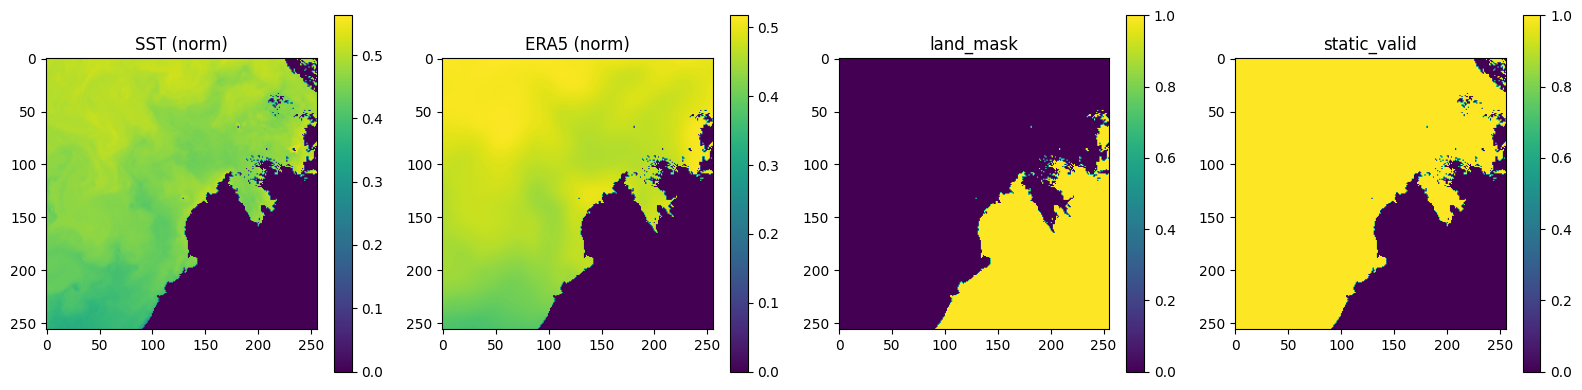

In [2]:
import matplotlib.pyplot as plt

idx = 0
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["SST (norm)", "ERA5 (norm)", "land_mask", "static_valid"]
data   = [batch["sst"][idx, 0], batch["era5"][idx, 0],
          batch["land_mask"][idx, 0], batch["static_valid"][idx, 0]]

for ax, d, t in zip(axes, data, titles):
    im = ax.imshow(d.numpy(), origin="upper")
    ax.set_title(t)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
# plt.savefig("debug_patch.png", dpi=150)

In [2]:
# debug_model.py
from patch_unet_for_sst import build_sst_unet
from sst_dataset import GeoTemporalEmbedding
import torch

model = build_sst_unet().cuda()
geo   = GeoTemporalEmbedding().cuda()

B, H, W = 2, 256, 256
dummy_input   = torch.randn(B, 3, H, W).cuda()
dummy_timestep = torch.randn(B, 1, H, W).cuda()
dummy_lat = torch.tensor([10.0, -5.0]).cuda()
dummy_lon = torch.tensor([120.0, 60.0]).cuda()
dummy_doy = torch.tensor([100.0, 200.0]).cuda()

geo_emb = geo(dummy_lat, dummy_lon, dummy_doy)
output  = model(dummy_input, dummy_timestep, geo_emb=geo_emb, return_dict=False)[0]

print(f"output shape: {output.shape}")   # 期望 [2, 1, 256, 256]
print(f"output range: {output.min():.3f} ~ {output.max():.3f}")
print(f"output nan: {output.isnan().any()}")


libgomp: Invalid value for environment variable OMP_NUM_THREADS


output shape: torch.Size([2, 1, 256, 256])
output range: -1.588 ~ 1.293
output nan: False


In [1]:
!echo $OMP_NUM_THREADS

0


In [ ]:
python train_SST_RAD.py \
    --data_root /path/to/sst_patches \
    --train_years 2022 \
    --val_years 2023 \
    --norm_stats_path norm_stats.json \
    --max_train_steps 20 \
    --train_batch_size 2 \
    --output_dir ./debug_output \
    --mixed_precision no \
    --report_to tensorboard

In [1]:
import sys, traceback
print("python executable:", sys.executable)
print("python version:", sys.version)

try:
    import numpy as np
    print("numpy import ok:", np.__version__)
    print("numpy file:", np.__file__)
except Exception:
    print("numpy import FAILED:")
    traceback.print_exc()

try:
    import torch
    print("torch import ok:", torch.__version__)
    print("torch built with cuda:", torch.version.cuda)
except Exception:
    print("torch import FAILED:")
    traceback.print_exc()

python executable: /root/miniconda3/bin/python
python version: 3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
numpy import ok: 1.26.4
numpy file: /root/miniconda3/lib/python3.10/site-packages/numpy/__init__.py
torch import ok: 2.1.2+cu121
torch built with cuda: 12.1


In [2]:
import numpy as np
import torch
print("numpy:", np.__version__, np.__file__)
print("torch:", torch.__version__)
a = np.zeros((2,3), dtype=np.float32)
print("np type:", type(a), a.dtype, a.flags['C_CONTIGUOUS'])
t = torch.from_numpy(a)
print("torch.from_numpy ok, tensor shape:", t.shape, t.dtype)

numpy: 1.26.4 /root/miniconda3/lib/python3.10/site-packages/numpy/__init__.py
torch: 2.1.2+cu121
np type: <class 'numpy.ndarray'> float32 True
torch.from_numpy ok, tensor shape: torch.Size([2, 3]) torch.float32
